In [4]:
pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
  Using cached kagglehub-1.0.1-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.25-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.1-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.25-py3-none-any.whl (228 kB)

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# loading the dataset

df=pd.read_csv("Titanic-Dataset.csv")



In [70]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [71]:
df.head(3)


# first we will see our data :-
df.info()
# we have datatype :-(int64 , float64)->{numerical data} (object)->{categorical data}


# cheaking the null values according to the columns
df.isnull().sum()
# printing some data abhout the dataset for understanding
print(df.columns)
print(f"rows=>{df.shape[0]}")
print(f"columns=>{df.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
rows=>891
columns=>12


In [72]:
# filling the null values 

# lets we make a function that fill the null values according to their type (float64,int64,object)

def fillnull(df):
    for col in df.columns:
        if(df[col].dtype=="int64" or df[col].dtype=="float64"):
            # filling the null values by mean:
            df[col].fillna(df[col].mean(),inplace=True)
        else:
            #filling by mode
            df[col].fillna(df[col].mode()[0],inplace=True) 
            


fillnull(df)



C:\Users\user\AppData\Local\Temp\ipykernel_19576\2490745268.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_19576\2490745268.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [73]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [74]:
# we have cleaned all null values according to all their type:-
# sinse ml dont work on categorical columns so we have to make the categoriczal col to numnerical

categorical_columns=[]
for col in df.columns:
    if df[col].dtype=="object":
        categorical_columns.append(col)

print(categorical_columns)


# lets see what kind of values these columns have
for col in categorical_columns:
    print(df[col].value_counts())


# from the analysis we can see that the columns sex and embarked have only two values so we can easily convert them to numerical by using map function or label encoder but the column ticket prefix have many values so we will drop it because it is not useful for our model .

# encoding..
df["Sex"]=df["Sex"].map({
    "male":0,
    "female":1
})
df["Embarked"]=df["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

# and now we drop the unuseful column






['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
392091 

In [ ]:
df.drop("Name",axis=1,inplace=True)

df.drop("Ticket",axis=1,inplace=True)

df.drop("Cabin",axis=1,inplace=True)

df.drop("PassengerId",axis=1,inplace=True)

In [88]:
# after encoding and dropping the unuseful columns we will see our data again


df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.000000,1,0,7.2500,0
1,1,1,1,38.000000,1,0,71.2833,1
2,1,3,1,26.000000,0,0,7.9250,0
3,1,1,1,35.000000,1,0,53.1000,0
4,0,3,0,35.000000,0,0,8.0500,0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.000000,0,0,13.0000,0
887,1,1,1,19.000000,0,0,30.0000,0
888,0,3,1,29.699118,1,2,23.4500,0
889,1,1,0,26.000000,0,0,30.0000,1


In [112]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000
mean,-0.132839,0.280435,-0.086583,-0.074313,-0.084625,-0.048616,-0.333425,-0.016964
std,0.959244,0.815489,0.969685,0.982750,0.832098,0.989401,0.207848,1.035643
min,-0.789272,-1.566107,-0.737695,-2.253155,-0.474545,-0.473674,-0.648422,-0.568837
25%,-0.789272,-0.369365,-0.737695,-0.592481,-0.474545,-0.473674,-0.489776,-0.568837
50%,-0.789272,0.827377,-0.737695,0.000000,-0.474545,-0.473674,-0.424256,-0.568837
75%,1.266990,0.827377,1.355574,0.254017,0.432793,-0.473674,-0.162169,-0.568837
max,1.266990,0.827377,1.355574,3.870872,4.062148,6.974147,0.388096,2.579199


In [ ]:
# importing the libraries for scaling the data
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Normalize/standardize the numerical features.

from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include=["int64", "float64"]).columns


scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

print(df.head())



   Survived    Pclass       Sex       Age     SibSp     Parch      Fare  \
0 -0.789272  0.827377 -0.737695 -0.592481  0.432793 -0.473674 -0.502445   
1  1.266990 -1.566107  1.355574  0.638789  0.432793 -0.473674  0.786845   
2  1.266990  0.827377  1.355574 -0.284663 -0.474545 -0.473674 -0.488854   
3  1.266990 -1.566107  1.355574  0.407926  0.432793 -0.473674  0.420730   
4 -0.789272  0.827377 -0.737695  0.407926 -0.474545 -0.473674 -0.486337   

   Embarked  
0 -0.568837  
1  1.005181  
2 -0.568837  
3 -0.568837  
4 -0.568837  


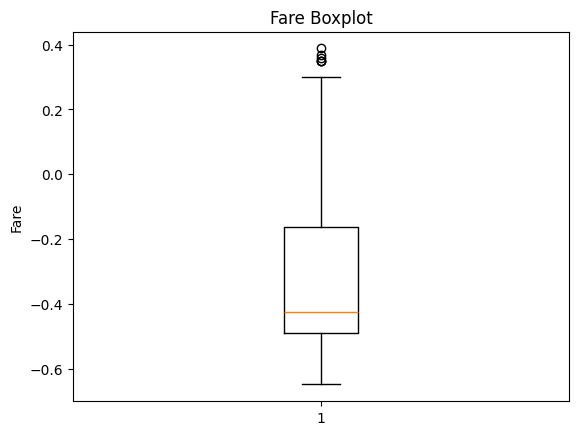

In [109]:

# lets see the outliers in the fare column by using boxplot
# we plot the boxplot for detecting the outliers


# the only valid column that can have outliers is fare 


import matplotlib.pyplot as plt
plt.boxplot(x="Fare" , data=df) 
plt.title("Fare Boxplot")
plt.ylabel("Fare")

plt.show()

In [ ]:
# removing the outliers by using IQR method


Q1 = df["Fare"].quantile(0.25)

Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
# we should note that it will be lies in this range [lower,upper]
# apply the outliers only once becauese we loss data which will affect performance of the ml model 
df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)] 